In [101]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from src.parameters import Parameters
from src.acquisition import Acquisition
from src.utilities import timer
from src.forward import forward
from src.plot.plot_tools import plot_seismogram

from src.reflectivity_kx_omega import reflectivity
from src.fortran.reflectivity_benchmark import fortran_reflectivity

In [103]:
# example from TOYxDAC_TIME
z_interfaces = np.array([0.0, 100.0, 200.0, 250.0, 350.0, 450.0, 550.0, 650.0, 700.0])
vp = np.array([1505.0, 1603.0, 1749.0, 2019.0, 2179.0, 1900.0, 2265.0, 3281.0])
rho = np.array([2000.0, 2000.0, 2000.0, 2000.0, 2000.0, 2000.0, 2000.0, 2000.0])

widths = np.diff(z_interfaces)
layers = [
    (widths[i], vp[i], rho[i])
    for i in range(len(vp))
]

print(layers)
'''layers = [
        (200.0, 1500.0, 2000.0), # top layer
        (300.0, 2500.0, 2000.0), # top layer width !!!
        (500.0, 4000.0, 2000.0),
    ]'''

[(np.float64(100.0), np.float64(1505.0), np.float64(2000.0)), (np.float64(100.0), np.float64(1603.0), np.float64(2000.0)), (np.float64(50.0), np.float64(1749.0), np.float64(2000.0)), (np.float64(100.0), np.float64(2019.0), np.float64(2000.0)), (np.float64(100.0), np.float64(2179.0), np.float64(2000.0)), (np.float64(100.0), np.float64(1900.0), np.float64(2000.0)), (np.float64(100.0), np.float64(2265.0), np.float64(2000.0)), (np.float64(50.0), np.float64(3281.0), np.float64(2000.0))]


'layers = [\n        (200.0, 1500.0, 2000.0), # top layer\n        (300.0, 2500.0, 2000.0), # top layer width !!!\n        (500.0, 4000.0, 2000.0),\n    ]'

In [104]:
total_time = 1.024    # seconds
f0 = 10.0           # Ricker central frequency (Hz)
f_max = 8.0 * f0    # practical Ricker cutoff
# Nyquist frequency for f_max
dt = 1/(2.*f_max)
print("dt =", dt)
#dt = total_time / (nt-1)
nfft = 2**int(np.ceil(np.log2(total_time/dt)))
nfft *= 8 # zero-padding to ensure late wrap-around
print("nfft =", nfft)
nt = int(total_time / dt) + 1
print("nt =", nt)
#time = np.arange(nt) * dt

epsilon = 1.0
param = Parameters(total_time=total_time, nt=nt, f0=f0, nfft=nfft, epsilon=epsilon, delay=0.1) 

# x and z positions of sources
xs, zs = 100.0, 50.0
sources = [(xs, zs)]
# x and z positions of receivers
Nr = 57
x_receivers = np.linspace(0.0, 700.0, Nr) # offsets
receivers = [(x, 75.0) for x in x_receivers]
print(receivers)
acq = Acquisition(sources, receivers)

dt = 0.00625
nfft = 2048
nt = 164
[(np.float64(0.0), 75.0), (np.float64(12.5), 75.0), (np.float64(25.0), 75.0), (np.float64(37.5), 75.0), (np.float64(50.0), 75.0), (np.float64(62.5), 75.0), (np.float64(75.0), 75.0), (np.float64(87.5), 75.0), (np.float64(100.0), 75.0), (np.float64(112.5), 75.0), (np.float64(125.0), 75.0), (np.float64(137.5), 75.0), (np.float64(150.0), 75.0), (np.float64(162.5), 75.0), (np.float64(175.0), 75.0), (np.float64(187.5), 75.0), (np.float64(200.0), 75.0), (np.float64(212.5), 75.0), (np.float64(225.0), 75.0), (np.float64(237.5), 75.0), (np.float64(250.0), 75.0), (np.float64(262.5), 75.0), (np.float64(275.0), 75.0), (np.float64(287.5), 75.0), (np.float64(300.0), 75.0), (np.float64(312.5), 75.0), (np.float64(325.0), 75.0), (np.float64(337.5), 75.0), (np.float64(350.0), 75.0), (np.float64(362.5), 75.0), (np.float64(375.0), 75.0), (np.float64(387.5), 75.0), (np.float64(400.0), 75.0), (np.float64(412.5), 75.0), (np.float64(425.0), 75.0), (np.float64(437.5), 75.0), (n

In [105]:
nthetas = 1024
thetas = np.linspace(0., np.pi/2., nthetas)
omegas = 2*np.pi * np.linspace(0.1, 20, 2048) + epsilon*1j

with timer("numpy reflectivity"):
    Rmap = reflectivity(layers, omegas + 0.1*1j, thetas, 76., 76., mode="k0",  use_numba=True, fs=True) 

p = np.sin(thetas) / layers[0][1]
with timer("Fortran reflectivity"):
    R_f = fortran_reflectivity(layers, omegas, p, free_surface=1, zr=76., zs=76.)

fixed_omega = 80.
omega_idx = np.argmin(np.abs(omegas - fixed_omega))
R_at_omega = np.abs(R_f[omega_idx, :])

omega_min = np.real(omegas[0])
omega_max = np.real(omegas[-1])
deg_min = 180.*thetas[0]/np.pi
deg_max = 180.*thetas[-1]/np.pi

elapsed: 1.69 s
numpy reflectivity elapsed: 1.71 s
Fortran reflectivity elapsed: 0.17 s


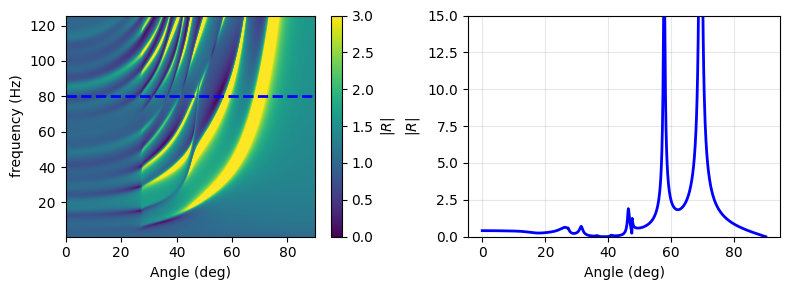

In [106]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.imshow(np.abs(Rmap), origin='lower',
            extent=(deg_min, deg_max, omega_min, omega_max),
            aspect='auto',
            vmin=0, vmax=3.0)
plt.axhline(y=fixed_omega, color='blue', linestyle='--', linewidth=2)
plt.xlabel('Angle (deg)')
plt.ylabel('frequency (Hz)')
plt.colorbar(label='$|R|$')

plt.subplot(1,2,2)

plt.plot(180.*thetas/np.pi, R_at_omega, 'b-', linewidth=2)

plt.xlabel('Angle (deg)')
plt.ylabel('$|R|$')
plt.grid(True, alpha=0.3)
plt.ylim([0, 15.0])
plt.tight_layout()
plt.show()

In [107]:
import numba
print("numba is using ", numba.get_num_threads() , " threads")

numba is using  22  threads


In [108]:
d_cal = forward(layers, acq, param, nq_prop=1024, free_surface=1, timing=True)

Sommerfeld quadrature elapsed: 1.71 s


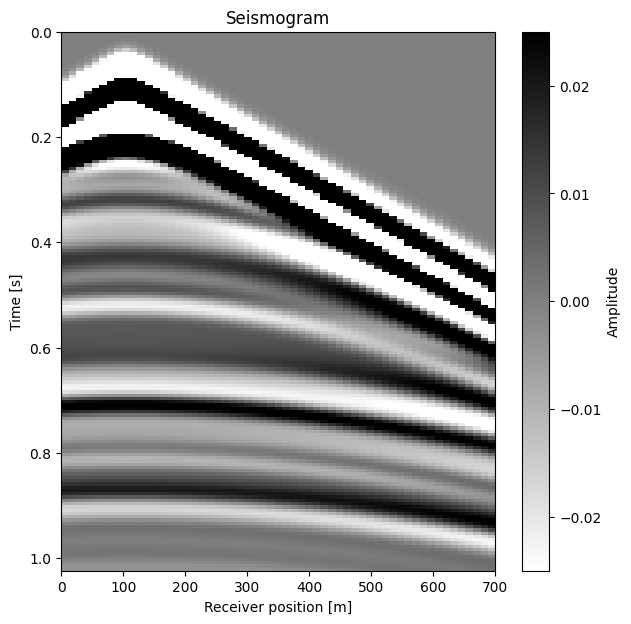

In [109]:
d_cal_seis = d_cal[0, :, :]
d_cal_seis = d_cal_seis / np.max(np.abs(d_cal_seis))  # normalize for better visualization
plot_seismogram(d_cal_seis.T, acq.xr, param.time, vmin=-0.025, vmax=0.025, cmap='gray_r', ncolors=256, figsize=(7, 7))
#plt.savefig("seismogram_reflectivity.png", bbox_inches='tight')

(57, 164)


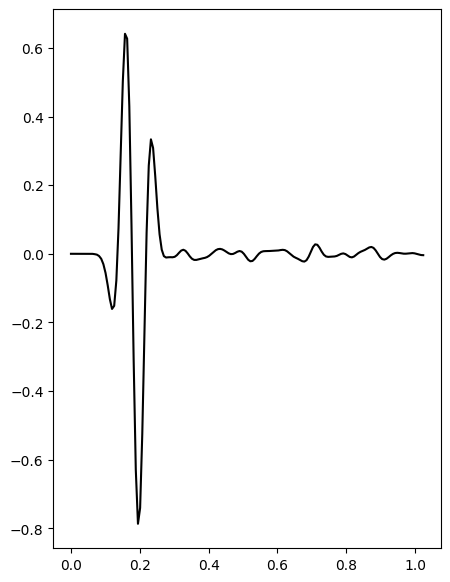

In [110]:
print(d_cal_seis.shape)
plt.figure(figsize=(5, 7))
plt.plot(param.time, d_cal_seis[0, :], 'k-')
plt.show()

#np.savetxt("../FD_comparison/d_cal_seis.txt", d_cal_seis)

(2048,)


Text(0.5, 0, 'Time (s)')

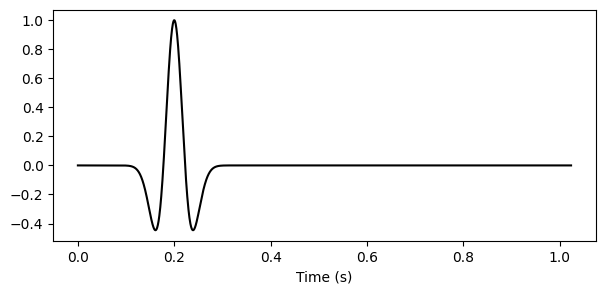

In [111]:
from src.utilities import ricker_wavelet
dt = 0.0005
nt = 2048
time = np.arange(nt) * dt
source_time = ricker_wavelet(time, param.f0)
print(source_time.shape)
plt.figure(figsize=(7, 3))
plt.plot(time, source_time, 'k-')
plt.xlabel('Time (s)')

#source_32 = source_time.astype(np.float32)
# Save to binary file
#filename = "fricker.bin"
#source_32.tofile(filename)
#print(f"File {filename} saved with {source_32.nbytes} bytes.")